In [1]:
%pip install -q torchmetrics
import torch
if torch.cuda.is_available():
    device='cuda'
else:
    device = 'cpu'
device

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.9 MB/s eta 0:00:0000:01


'cuda'

In [2]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()['images'])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [3]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [ ]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

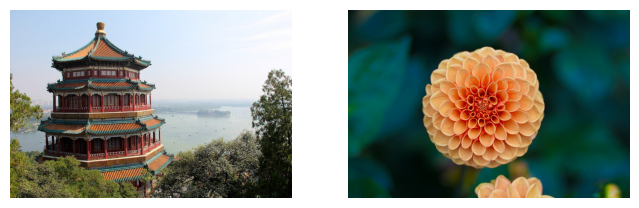

In [5]:
import matplotlib.pyplot as plt
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

In [6]:
import torchvision
import torchvision.transforms.v2 as T
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

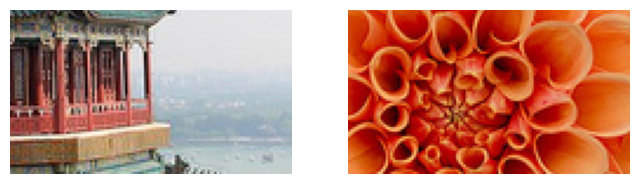

In [7]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [8]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32,kernel_size=7)
fmaps= conv_layer(cropped_images)

In [9]:
fmaps.shape

torch.Size([2, 32, 64, 114])

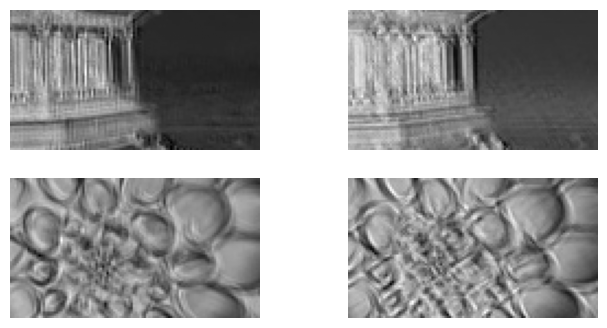

In [10]:
# extra code – displays the two output feature maps for each image

plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")

plt.show()

In [11]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7,
                       padding='same')
fmaps = conv_layer(cropped_images)

In [12]:
fmaps.shape

torch.Size([2, 32, 70, 120])

In [13]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                       padding=3)
fmaps= conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 35, 60])

In [14]:
conv_layer.weight.shape

torch.Size([32, 3, 7, 7])

In [15]:
conv_layer.bias.shape

torch.Size([32])

In [16]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])
biases = torch.zeros([2])
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

In [17]:
fmaps.shape

torch.Size([2, 2, 70, 120])

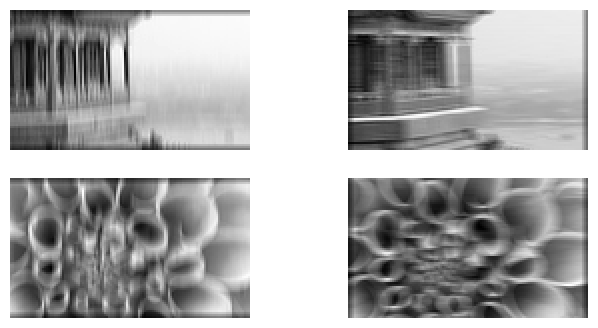

In [18]:
# extra code – shows how to manually create two filters to get images similar
#              to those in Figure 12–5.

plt.figure(figsize=(8, 4))
filters = torch.zeros([2, 3, 7, 7])
filters[0, :, :, 3] = 1
filters[1, :, 3, :] = 1
fmaps = F.conv2d(cropped_images, filters, biases, stride=1, padding="same")

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

In [19]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [20]:
output_max = max_pool(cropped_images)

In [21]:
avg_pool = nn.AvgPool2d(kernel_size=2)

In [22]:
output_avg = avg_pool(cropped_images)

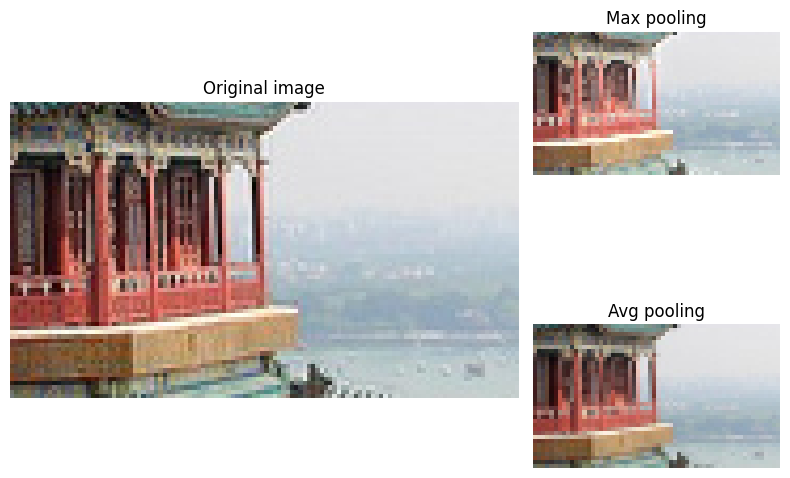

In [23]:

fig = plt.figure(figsize=(8, 6))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Original image")

ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()


In [30]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding
    
    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height * width)
        Z = Z.permute(0, 2, 1)
        Z = F.maz_pool1d(Z, kernel_size = self.kernel_size, stride=self.stride,
                         padding=self.padding)
        Z = Z.permute(0,2,1)
        return Z.view(batch, -1, height, width)

In [31]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))

In [32]:
output = global_avg_pool(cropped_images)

In [33]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)

In [34]:
output = global_avg_pool(cropped_images)

In [35]:
output = cropped_images.mean(dim=(2,3), keepdim=True)

In [36]:
from functools import partial

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding='same')
model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [37]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [38]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


In [39]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [41]:
n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.9941, train metric: 0.6205, valid metric: 0.8016
Epoch 2/20, train loss: 0.5741, train metric: 0.7877, valid metric: 0.8280
Epoch 3/20, train loss: 0.4974, train metric: 0.8185, valid metric: 0.8616
Epoch 4/20, train loss: 0.4418, train metric: 0.8468, valid metric: 0.8668
Epoch 5/20, train loss: 0.4032, train metric: 0.8626, valid metric: 0.8752
Epoch 6/20, train loss: 0.3760, train metric: 0.8717, valid metric: 0.8890
Epoch 7/20, train loss: 0.3580, train metric: 0.8779, valid metric: 0.8884
Epoch 8/20, train loss: 0.3370, train metric: 0.8870, valid metric: 0.8876
Epoch 9/20, train loss: 0.3257, train metric: 0.8901, valid metric: 0.8956
Epoch 10/20, train loss: 0.3090, train metric: 0.8945, valid metric: 0.8942
Epoch 11/20, train loss: 0.2978, train metric: 0.8989, valid metric: 0.9010
Epoch 12/20, train loss: 0.2843, train metric: 0.9041, valid metric: 0.9006
Epoch 13/20, train loss: 0.2838, train metric: 0.9031, valid metric: 0.8964
Epoch 14/20, train lo